# 數位世代國七生教養與心理困擾分析

**2026 資料科學漫步競賽**

**研究問題**：數位世代國七生的家庭教養經驗（家庭支持、親子互動溫暖/嚴厲、家長參與、父母未來
期待、學業要求）與心理困擾之間的關聯為何？連同性別、家庭結構、家庭經濟、照顧者教育、學業表現、
同儕支持、霸凌/網路霸凌受害、網路成癮等脈絡因素，哪些因素與心理困擾的關聯較強、相對重要性較高？

分析流程依序為：資料讀取與變數建構 → 相關矩陣與VIF
共線性檢查 → 敘述性統計 → 信度檢驗 → 潛在剖面分析(LPA，教養剖繪分型) → 單因子ANOVA與ANCOVA
(含假設檢定) → 機器學習(Random Forest / XGBoost，含逐步迴歸與LASSO對照) → SHAP特徵重要性。

In [30]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pingouin as pg
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import jarque_bera
from stepmix.stepmix import StepMix

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
import shap

from scipy import stats
from scipy.stats import levene
from scipy.stats import qmc
from matplotlib.colors import LinearSegmentedColormap

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", font="Microsoft JhengHei")
plt.rcParams['axes.unicode_minus'] = False  
pd.set_option("display.max_columns", 100)

CAT_PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#4a3aa7']
SEQ_BLUE = '#2a78d6'
DIVERGING_CMAP = LinearSegmentedColormap.from_list('blue_red_diverging', ['#184f95', '#f0efec', '#e34948'])

STUDENT_CSV = r"D00262\標準版\01_學生\TIGPSw1_s.csv"
MISSING_CODES = [-4, -5, -6, -7, -8, -9, -99, -999]  # TIGPS遺漏值代碼


def recode_missing(df, codes):
    '''將指定的遺漏值代碼轉為NaN。'''
    return df.mask(df.isin(codes))


def build_scale(df, items, name, agg='sum', floor_mask=None, floor_value=None):
    '''清理遺漏值後計算量表分數(任一構成題項缺失則整體設為缺失)，並印出N與Cronbach's alpha供
    信度檢核。floor_mask/floor_value: 將跳答(如「從未遇過霸凌」)填入該量表的理論最低值，而非當作缺失。
    '''
    sub = recode_missing(df[items], MISSING_CODES).astype(float)
    if floor_mask is not None:
        sub.loc[floor_mask, :] = floor_value
    if agg == 'sum':
        score = sub.sum(axis=1, skipna=False)
    else:
        score = sub.mean(axis=1, skipna=False)
    n_valid = score.notna().sum()
    alpha = np.nan
    if len(items) >= 2:
        valid_sub = sub.dropna()
        if len(valid_sub) >= 30:
            alpha = pg.cronbach_alpha(data=valid_sub)[0]
    flag = '' if (np.isnan(alpha) or alpha >= 0.7) else '  ⚠ alpha<0.7'
    print(f"{name:30s} items={len(items):2d}  N_valid={n_valid:5d}  alpha={alpha:.3f}{flag}" if not np.isnan(alpha)
          else f"{name:30s} items={len(items):2d}  N_valid={n_valid:5d}  alpha=n/a(單題或樣本過小)")
    return score


def sobol_hyperparam_search(model_class, param_specs, X, y, n_samples_pow2=5, cv_folds=5):
    '''以Sobol低差異序列在指定的超參數空間取樣2**n_samples_pow2個候選點，用K-fold交叉驗證(R²)
    評分，回傳依CV R²排序的完整搜尋結果表，第一列即為最佳超參數組合。
    '''
    names = list(param_specs.keys())
    l_bounds = [param_specs[n][0] for n in names]
    u_bounds = [param_specs[n][1] for n in names]

    sampler = qmc.Sobol(d=len(names), scramble=True, seed=RANDOM_STATE)
    raw = sampler.random_base2(m=n_samples_pow2)
    scaled = qmc.scale(raw, l_bounds, u_bounds)

    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    records = []
    for row in scaled:
        params = {}
        for name, val in zip(names, row):
            is_int = param_specs[name][2]
            params[name] = int(round(val)) if is_int else float(val)
        model = model_class(**params, random_state=RANDOM_STATE)
        score = cross_val_score(model, X, y, cv=kf, scoring='r2').mean()
        records.append({**params, 'cv_R2': score})

    results = pd.DataFrame(records).sort_values('cv_R2', ascending=False).reset_index(drop=True)
    best_params = {name: results.loc[0, name] for name in names}
    for name in names:
        if param_specs[name][2]:
            best_params[name] = int(best_params[name])
    return best_params, results


def stepwise_select(data, dv, main_vars, include_interactions=False, verbose=False):
    '''逐步迴歸(stepwise regression)，以 BIC 為準則。從空模型開始，每輪嘗試加入一個能讓
    BIC下降最多的變項，加入後再檢查是否有變項可以移除讓BIC更低，直到沒有變項可再加入或移除為止。

    include_interactions=True時，候選集合除了主效果外，還會納入兩兩交互作用項(A:B)。
    一個交互作用項A:B，只有在A、B兩個主效果都已經被選入模型後，才有資格成為候選項；
    反向剔除時，若某個主效果仍有依賴它的交互作用項留在模型裡，則暫不考慮剔除該主效果，確保模型可解釋。'''
    included, remaining_main = [], list(main_vars)
    current_ic = smf.ols(f"{dv} ~ 1", data=data).fit().bic
    improved = True
    while improved:
        improved = False
        candidates = list(remaining_main)
        if include_interactions:
            for i in range(len(included)):
                for j in range(i + 1, len(included)):
                    a, b = included[i], included[j]
                    if a in main_vars and b in main_vars:
                        term = f"{a}:{b}"
                        if term not in included:
                            candidates.append(term)

        best_ic, best_var = current_ic, None
        for v in candidates:
            ic = smf.ols(f"{dv} ~ " + " + ".join(included + [v]), data=data).fit().bic
            if ic < best_ic:
                best_ic, best_var = ic, v
        if best_var is not None:
            included.append(best_var)
            if best_var in remaining_main:
                remaining_main.remove(best_var)
            current_ic = best_ic
            improved = True
            if verbose:
                print(f"  + {best_var} (BIC={best_ic:.2f})")

        if len(included) > 1:
            best_ic2, worst_var = current_ic, None
            for v in included:
                if include_interactions and ':' not in v:
                    depends = [t for t in included if ':' in t and v in t.split(':')]
                    if depends:
                        continue  # 還有交互作用項依賴這個主效果，暫不能移除
                trial = [x for x in included if x != v]
                formula = f"{dv} ~ " + (" + ".join(trial) if trial else "1")
                ic = smf.ols(formula, data=data).fit().bic
                if ic < best_ic2:
                    best_ic2, worst_var = ic, v
            if worst_var is not None:
                included.remove(worst_var)
                if ':' not in worst_var and worst_var not in remaining_main:
                    remaining_main.append(worst_var)
                current_ic = best_ic2
                improved = True
                if verbose:
                    print(f"  - {worst_var} (BIC={best_ic2:.2f})")
    final_model = smf.ols(f"{dv} ~ " + " + ".join(included), data=data).fit()
    return included, final_model


def build_design(X_base, terms):
    d = pd.DataFrame(index=X_base.index)
    for t in terms:
        parts = t.split(' ')
        col = X_base[parts[0]].copy()
        for p in parts[1:]:
            col = col * X_base[p]
        d[t.replace(' ', ':')] = col
    return d


def print_model_table_and_equation(model, dv_name='distress_total', label='', decimals=3):
    print(f"=== {label} ===")
    coef_table = pd.DataFrame({
        '係數': model.params, '標準誤': model.bse, 'p值': model.pvalues,
    }).round(4)
    print(coef_table.to_string())

    intercept_candidates = [n for n in model.params.index if n.lower() in ('intercept', 'const')]
    intercept_name = intercept_candidates[0] if intercept_candidates else None

    eq_terms = []
    if intercept_name is not None:
        eq_terms.append(f"{model.params[intercept_name]:.{decimals}f}")
    for name in model.params.index:
        if name == intercept_name:
            continue
        coef = model.params[name]
        sign = '+' if coef >= 0 else '-'
        var_str = name.replace(':', '×')
        eq_terms.append(f"{sign} {abs(coef):.{decimals}f}×{var_str}")
    equation = f"{dv_name} = " + " ".join(eq_terms)
    print(f"\n配適方程式：\n{equation}\n")
    return coef_table, equation

## 1. 資料讀取與分析母體

In [2]:
df_s = pd.read_csv(STUDENT_CSV, low_memory=False)
print(f"學生問卷: {df_s.shape[0]} 筆, {df_s.shape[1]} 欄")

# 學生問卷有兩組互斥的題本模組，本研究需要的親子互動/家長參與/父母期待等題組屬於「家庭模組」
# (由response卷別變項標示為1、2、4)，故以此界定分析母體
has_family_module = df_s['response'].isin([1, 2, 4])
df = df_s[has_family_module].copy().reset_index(drop=True)
print(f"分析樣本: N = {len(df)}")

學生問卷: 8958 筆, 670 欄
分析樣本: N = 4826


## 2. 變數建構

把題項加總/平均成量表分數，量表分數只要任一構成題項缺失，該量表分數就設為缺失(`build_scale`內
`skipna=False`)。

### 核心自變項
家庭支持（as9a-f，6題）／親子互動溫暖(as12b,c,d,j)、負向嚴厲(as12a,e,f,h,i)、
  監控(as12g) ／家長參與(as24a-j，10題) ／父母未來期待(as23a-d，4題) ／家長學業要求(as21，次序1-4)

### 控制變項
性別(as1)、家庭結構(as3，簡化為父母已婚同住二元指標)、照顧者教育(as4d1)、家庭經濟(as10)、
學業表現(as19+as20反轉)、同儕支持(as42a,c,d,e)、霸凌受害(as51/as51a)、
網路霸凌受害(as53/as53a)

### 依變項
心理困擾(as72a-l，12題) 

In [3]:
ITEM_GROUPS = {
    "distress_total": [f"as72{c}" for c in "abcdefghijkl"],
    "family_support": [f"as9{c}" for c in "abcdef"],
    "parent_warmth": ["as12b", "as12c", "as12d", "as12j"],
    "parent_harsh": ["as12a", "as12e", "as12f", "as12h", "as12i"],
    "parent_monitor": ["as12g"],
    "parent_involvement": [f"as24{c}" for c in "abcdefghij"],
    "parent_expect": [f"as23{c}" for c in "abcd"],
    "academic_demand": ["as21"],
    "peer_support": ["as42a", "as42c", "as42d", "as42e"],
    "bully_items": [f"as51a{i}" for i in range(1, 9)],
    "cyberbully_items": [f"as53a{i}" for i in range(1, 8)],
    "net_addiction": [f"as41{c}" for c in "abcdefghij"],
}

dep_items = ITEM_GROUPS["distress_total"]
family_support_items = ITEM_GROUPS["family_support"]
warmth_items = ITEM_GROUPS["parent_warmth"]
harsh_items = ITEM_GROUPS["parent_harsh"]
parent_involve_items = ITEM_GROUPS["parent_involvement"]
expect_items = ITEM_GROUPS["parent_expect"]
peer_items = ITEM_GROUPS["peer_support"]
bully_items = ITEM_GROUPS["bully_items"]
cyberbully_items = ITEM_GROUPS["cyberbully_items"]
addiction_items = ITEM_GROUPS["net_addiction"]

In [4]:
df['distress_total'] = build_scale(df, dep_items, 'as72 心理困擾總分')

df['family_support'] = build_scale(df, family_support_items, 'as9 家庭支持', agg='mean')
df['parent_warmth'] = build_scale(df, warmth_items, 'as12 親子互動-溫暖支持')
df['parent_harsh'] = build_scale(df, harsh_items, 'as12 親子互動-負向嚴厲')
df['parent_monitor'] = recode_missing(df[['as12g']], MISSING_CODES)['as12g']
df['parent_involvement'] = build_scale(df, parent_involve_items, 'as24 家長參與', agg='mean')
df['parent_expect'] = build_scale(df, expect_items, 'as23 父母未來期待', agg='mean')

as21_raw = recode_missing(df[['as21']], MISSING_CODES)['as21']
df['academic_demand'] = as21_raw.where(as21_raw.isin([1, 2, 3, 4]))  # (5)其他不構成單調次序，設為缺失

as72 心理困擾總分                    items=12  N_valid= 4746  alpha=0.930
as9 家庭支持                       items= 6  N_valid= 4808  alpha=0.897
as12 親子互動-溫暖支持                 items= 4  N_valid= 4778  alpha=0.852
as12 親子互動-負向嚴厲                 items= 5  N_valid= 4778  alpha=0.737
as24 家長參與                      items=10  N_valid= 4772  alpha=0.829
as23 父母未來期待                    items= 4  N_valid= 4770  alpha=0.837


In [5]:
df['male'] = (recode_missing(df[['as1']], MISSING_CODES)['as1'] == 2).astype(float)

as3_raw = recode_missing(df[['as3']], MISSING_CODES)['as3']
df['family_intact'] = (as3_raw == 1).astype(float)

df['caregiver_edu'] = recode_missing(df[['as4d1']], MISSING_CODES)['as4d1']
df['family_ses'] = recode_missing(df[['as10']], MISSING_CODES)['as10']

as19_raw = recode_missing(df[['as19']], MISSING_CODES)['as19']
df['academic_progress'] = as19_raw
df['academic_rank'] = 6 - recode_missing(df[['as20']], MISSING_CODES)['as20']

df['peer_support'] = build_scale(df, peer_items, 'as42 同儕支持(排除b題)', agg='mean')

as51_screen = recode_missing(df[['as51']], MISSING_CODES)['as51']
never_bullied = (as51_screen == 2)
df['bully_victim'] = build_scale(df, bully_items, 'as51 實際生活霸凌受害', agg='mean',
                                  floor_mask=never_bullied, floor_value=1)

as53_screen = recode_missing(df[['as53']], MISSING_CODES)['as53']
never_cyberbullied = (as53_screen == 2)
df['cyberbully_victim'] = build_scale(df, cyberbully_items, 'as53 網路霸凌受害', agg='mean',
                                       floor_mask=never_cyberbullied, floor_value=1)

df['net_addiction'] = build_scale(df, addiction_items, 'as41 網路成癮')

ANCOVA_CONTROLS = ['male', 'family_intact', 'caregiver_edu', 'family_ses',
                    'academic_progress', 'academic_rank', 'peer_support',
                    'bully_victim', 'cyberbully_victim']

SCALE_VARS = ['distress_total', 'family_support', 'parent_warmth', 'parent_harsh', 'parent_monitor',
              'parent_involvement', 'parent_expect', 'academic_demand',
              'male', 'family_intact', 'caregiver_edu', 'family_ses',
              'academic_progress', 'academic_rank', 'peer_support',
              'bully_victim', 'cyberbully_victim', 'net_addiction']

as42 同儕支持(排除b題)                items= 4  N_valid= 4803  alpha=0.911
as51 實際生活霸凌受害                  items= 8  N_valid= 4799  alpha=0.911
as53 網路霸凌受害                    items= 7  N_valid= 4799  alpha=0.911
as41 網路成癮                      items=10  N_valid= 4799  alpha=0.910


## 3. 相關矩陣、VIF共線性檢查

家庭支持、教養溫暖、教養嚴厲、家長參與這四個教養變項在概念上高度重疊，這裡用相關矩陣
檢查、再用VIF(變異數膨脹因子)量化檢查是否嚴重共線——如果VIF偏高(經驗法則:>5嚴格、>10寬鬆)，
代表這幾個變項不適合同時當作個別預測變項放進同一個迴歸。

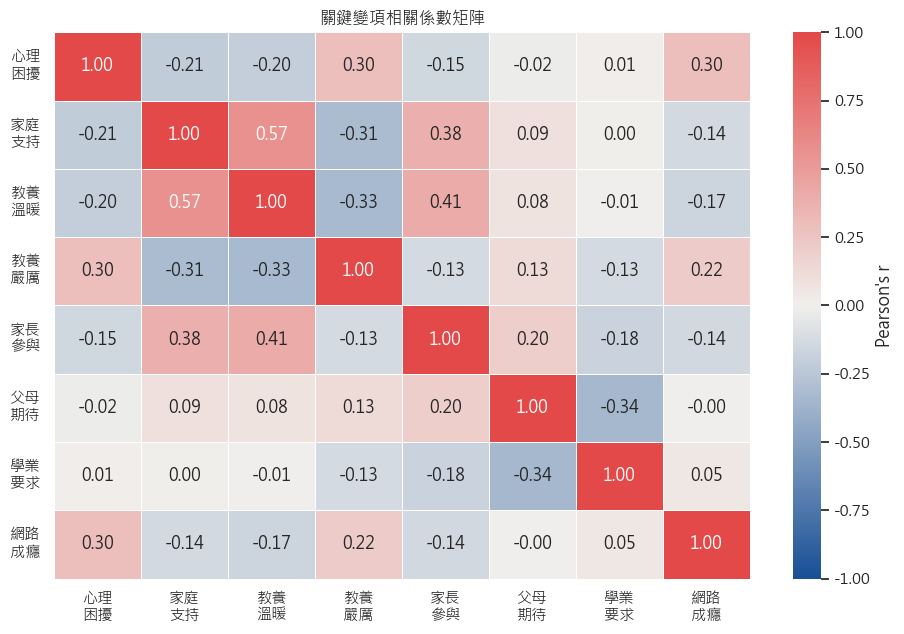

家庭支持 vs 教養溫暖: r=0.568
家庭支持 vs 家長參與: r=0.380
教養溫暖 vs 家長參與: r=0.408


In [6]:
corr_vars = ['distress_total', 'family_support', 'parent_warmth', 'parent_harsh',
             'parent_involvement', 'parent_expect', 'academic_demand', 'net_addiction']
corr_labels = ['心理\n困擾', '家庭\n支持', '教養\n溫暖', '教養\n嚴厲', '家長\n參與',
               '父母\n期待', '學業\n要求', '網路\n成癮']
corr_mat = df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(9.5, 6.5))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap=DIVERGING_CMAP, vmin=-1, vmax=1,
            xticklabels=corr_labels, yticklabels=corr_labels, ax=ax,
            cbar_kws={'label': "Pearson's r"}, linewidths=0.5, linecolor='white')
ax.set_title('關鍵變項相關係數矩陣')
ax.set_xticklabels(corr_labels, rotation=0, ha='center')
ax.set_yticklabels(corr_labels, rotation=0)
plt.tight_layout()
plt.show()

print(f"家庭支持 vs 教養溫暖: r={corr_mat.loc['family_support','parent_warmth']:.3f}")
print(f"家庭支持 vs 家長參與: r={corr_mat.loc['family_support','parent_involvement']:.3f}")
print(f"教養溫暖 vs 家長參與: r={corr_mat.loc['parent_warmth','parent_involvement']:.3f}")

In [31]:
vif_vars = ['family_support', 'parent_warmth', 'parent_harsh', 'parent_involvement']
vif_df = df[vif_vars].dropna()
vif_data = pd.DataFrame({
    '變項': vif_vars,
    'VIF': [variance_inflation_factor(vif_df.values, i) for i in range(len(vif_vars))],
})
print(f"VIF共線性檢查 (N={len(vif_df)})：")
print(vif_data.to_string(index=False))

VIF共線性檢查 (N=4746)：
                變項      VIF
    family_support 1.577335
     parent_warmth 1.653112
      parent_harsh 1.157767
parent_involvement 1.254268


## 4. 敘述性統計

In [10]:
continuous_vars = {
    'distress_total': '心理困擾總分(0-48)', 'family_support': '家庭支持(1-4)',
    'parent_warmth': '親子互動-溫暖支持(4-16)', 'parent_harsh': '親子互動-負向嚴厲(5-20)',
    'parent_monitor': '親子互動-監控(1-4)', 'parent_involvement': '家長參與(1-4)',
    'parent_expect': '父母未來期待(1-10)', 'caregiver_edu': '照顧者教育(1-9)',
    'family_ses': '主觀家庭經濟(1-4)', 'academic_progress': '跟得上進度(1-5)',
    'academic_rank': '班排名(反轉,1-5,高=好)', 'peer_support': '同儕支持(1-4)',
    'bully_victim': '實際生活霸凌受害(1-4)', 'cyberbully_victim': '網路霸凌受害(1-4)',
    'net_addiction': '網路成癮(10-40)',
}
rows = []
for col, label in continuous_vars.items():
    s = df[col]
    rows.append({
        '變項': col, '說明': label, 'N': s.notna().sum(),
        '缺失比例(%)': round((1 - s.notna().sum() / len(df)) * 100, 1),
        '平均數': round(s.mean(), 2), '標準差': round(s.std(), 2),
        '偏態': round(s.skew(), 2), '最小值': s.min(), '最大值': s.max(),
    })
desc_df = pd.DataFrame(rows).sort_values('缺失比例(%)')
print(f"連續變項描述統計 (N={len(df)})：\n")
desc_df

連續變項描述統計 (N=4826)：



,變項,說明,N,缺失比例(%),平均數,標準差,偏態,最小值,最大值
8,family_ses,主觀家庭經濟(1-4),4812,0.3,2.77,0.56,-0.90,1.0,4.0
1,family_support,家庭支持(1-4),4808,0.4,3.19,0.71,-0.94,1.0,4.0
9,academic_progress,跟得上進度(1-5),4808,0.4,3.36,1.11,-0.59,1.0,5.0
11,peer_support,同儕支持(1-4),4803,0.5,3.18,0.72,-0.87,1.0,4.0
12,bully_victim,實際生活霸凌受害(1-4),4799,0.6,1.21,0.47,2.83,1.0,4.0
14,net_addiction,網路成癮(10-40),4799,0.6,19.20,6.68,0.46,10.0,40.0
13,cyberbully_victim,網路霸凌受害(1-4),4799,0.6,1.08,0.30,4.96,1.0,4.0
2,parent_warmth,親子互動-溫暖支持(4-16),4778,1.0,12.38,3.05,-0.60,4.0,16.0
4,parent_monitor,親子互動-監控(1-4),4778,1.0,2.92,1.07,-0.45,1.0,4.0
3,parent_harsh,親子互動-負向嚴厲(5-20),4778,1.0,9.59,3.09,0.80,5.0,20.0


## 5. 信度檢驗（Cronbach's α，α≥.7才加總）

檢驗同一量表底下的題項，內部一致性是否足夠支持加總成一個量表分數。

In [32]:
reliability_summary = {
    'as72 心理困擾(12題)': dep_items, 'as9 家庭支持(6題)': family_support_items,
    'as12 溫暖支持(4題)': warmth_items, 'as12 負向嚴厲(5題)': harsh_items,
    'as24 家長參與(10題)': parent_involve_items, 'as23 父母期待(4題)': expect_items,
    'as42 同儕支持(4題)': peer_items,
}
rows = []
for name, items in reliability_summary.items():
    valid_sub = recode_missing(df[items], MISSING_CODES).dropna()
    alpha = pg.cronbach_alpha(data=valid_sub)[0]
    rows.append({'量表': name, 'N': len(valid_sub), 'alpha': round(alpha, 3),
                 '判定': '✓ 可加總' if alpha >= 0.7 else '⚠ 未達.70門檻'})
pd.DataFrame(rows)

,量表,N,alpha,判定
0,as72 心理困擾(12題),4746,0.930,✓ 可加總
1,as9 家庭支持(6題),4808,0.897,✓ 可加總
2,as12 溫暖支持(4題),4778,0.852,✓ 可加總
3,as12 負向嚴厲(5題),4778,0.737,✓ 可加總
4,as24 家長參與(10題),4772,0.829,✓ 可加總
5,as23 父母期待(4題),4770,0.837,✓ 可加總
6,as42 同儕支持(4題),4803,0.911,✓ 可加總


## 6. 潛在剖面分析（LPA）：教養剖繪類型

**方法說明**：家庭支持、教養溫暖、教養嚴厲、家長參與這4個連續指標彼此中度相關，這裡改用LPA把
樣本分成幾個質性不同的教養型態群組(剖繪/profile)。LPA基於機率模型，每個人有屬於各群的機率，可以算entropy分類品質指標。

**判斷群數k**：entropy越接近1代表分類邊界越清晰，BIC越低配適越好，這裡以entropy為主要判準。

**剖面命名**：看`profile_means`表列出每一群在4個指標上的平均值，找出「相對其他群，這
一群在哪些指標上偏高/偏低」；標準化輪廓圖(z-score)則是把不同量尺的指標轉成「距離全樣本平均幾個標準差」，方便判斷差異的相對幅度。

In [12]:
LPA_INDICATORS = ['family_support', 'parent_warmth', 'parent_harsh', 'parent_involvement']
lpa_df = df[LPA_INDICATORS].dropna()
print(f"LPA可用樣本數: {len(lpa_df)} / {len(df)}")

X_lpa = (lpa_df - lpa_df.mean()) / lpa_df.std()

results = []
for k in range(2, 6):
    model = StepMix(n_components=k, measurement='gaussian_tied', random_state=RANDOM_STATE,
                     n_init=15, verbose=0, progress_bar=0)
    model.fit(X_lpa.values)
    bic = model.bic(X_lpa.values)
    proba = model.predict_proba(X_lpa.values)
    eps = 1e-10
    entropy = -np.sum(proba * np.log(proba + eps), axis=1)
    max_entropy = np.log(k)
    relative_entropy = 1 - entropy.mean() / max_entropy
    results.append({'k': k, 'BIC': bic, 'Entropy': relative_entropy})

results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df['Entropy'].idxmax()]
final_k = int(best_row['k'])
print(results_df.to_string(index=False))
print(f"\n最終選定群數: k = {final_k}（entropy為主要判準）")

final_model = StepMix(n_components=final_k, measurement='gaussian_tied', random_state=RANDOM_STATE,
                       n_init=20, verbose=0, progress_bar=0)
final_model.fit(X_lpa.values)
lpa_df = lpa_df.copy()
lpa_df['profile'] = final_model.predict(X_lpa.values)
df.loc[lpa_df.index, 'parenting_profile'] = lpa_df['profile']

profile_counts = lpa_df['profile'].value_counts().sort_index()
print(f"\n各剖面人數：\n{profile_counts}")

profile_means = lpa_df.groupby('profile')[LPA_INDICATORS].mean().round(2)
print("\n各剖面在四個指標上的平均值(原始量尺)：")
print(profile_means)

LPA可用樣本數: 4746 / 4826
 k          BIC  Entropy
 2 50414.817530 0.000034
 3 48886.712743 0.791846
 4 48929.038031 0.450786
 5 48879.631076 0.354846

最終選定群數: k = 3（entropy為主要判準）

各剖面人數：
profile
0     828
1    3797
2     121
Name: count, dtype: int64

各剖面在四個指標上的平均值(原始量尺)：
         family_support  parent_warmth  parent_harsh  parent_involvement
profile                                                                 
0                  2.24           8.86         12.10                2.31
1                  3.45          13.15          9.05                2.83
2                  1.17          12.70          9.63                3.12


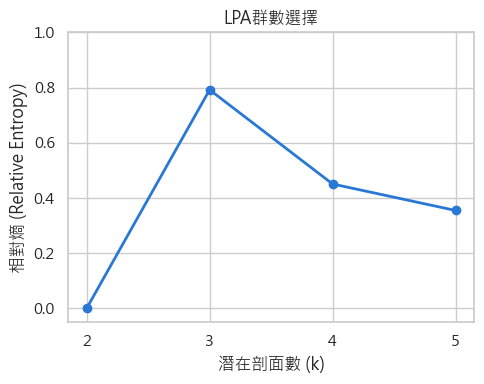

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(results_df['k'], results_df['Entropy'], marker='o', color=SEQ_BLUE, linewidth=2)
ax.set_xlabel('潛在剖面數 (k)')
ax.set_ylabel('相對熵 (Relative Entropy)')
ax.set_title('LPA群數選擇')
ax.set_xticks(results_df['k'])
ax.set_ylim(-0.05, 1.0)
plt.tight_layout()
plt.show()

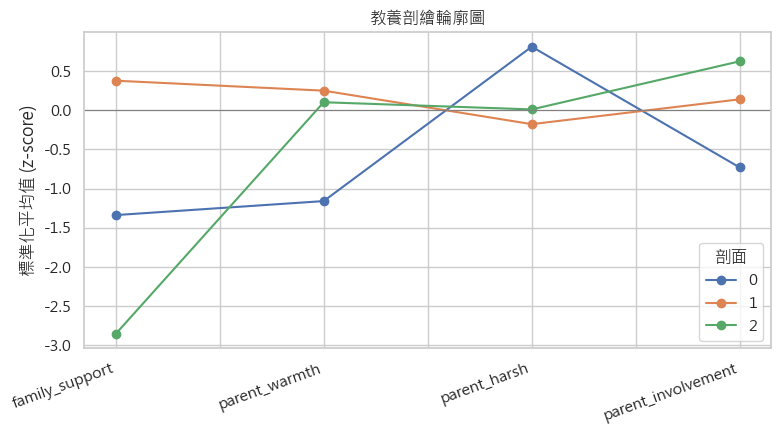

In [14]:
profile_z = (profile_means - lpa_df[LPA_INDICATORS].mean()) / lpa_df[LPA_INDICATORS].std()
fig, ax = plt.subplots(figsize=(8, 4.5))
profile_z.T.plot(marker='o', ax=ax)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_ylabel('標準化平均值 (z-score)')
ax.set_title('教養剖繪輪廓圖')
ax.legend(title='剖面')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

**解讀**：y軸是z-score(標準化平均值)，0水平線代表「全樣本平均」。每一條線代表一個
剖面，一條線如果在「家庭支持、教養溫暖、家長參與」都在0以上(正值，高於平均)、在「教養嚴厲」在0以下(負值，低於平均)，這條線代表的剖面就是「支持型」教養；如果一條線在「教養嚴厲」是正值、其他三項是負值，就是「嚴厲/低支持型」。線與線之間分得越開，代表剖面之間的區分度越好；如果一條線在某個指標上剛好穿過0附近，代表那個剖面在那個指標上跟全樣本平均沒有太大差異，不是這個剖面的顯著特徵。

對照各剖面在四個指標上的相對高低，可以命名成「溫暖支持型」、「低支持高嚴厲型」等型態。

### 心理困擾總分：整體分佈 與 按教養剖繪分組比較

左圖看整體分佈形狀（是否偏態），右圖看三個教養剖繪的心理困擾總分是否有明顯差異，呼應ANCOVA變異數同質性檢定，三者離散程度如果明顯不同，即Levene檢定顯著的視覺版本。

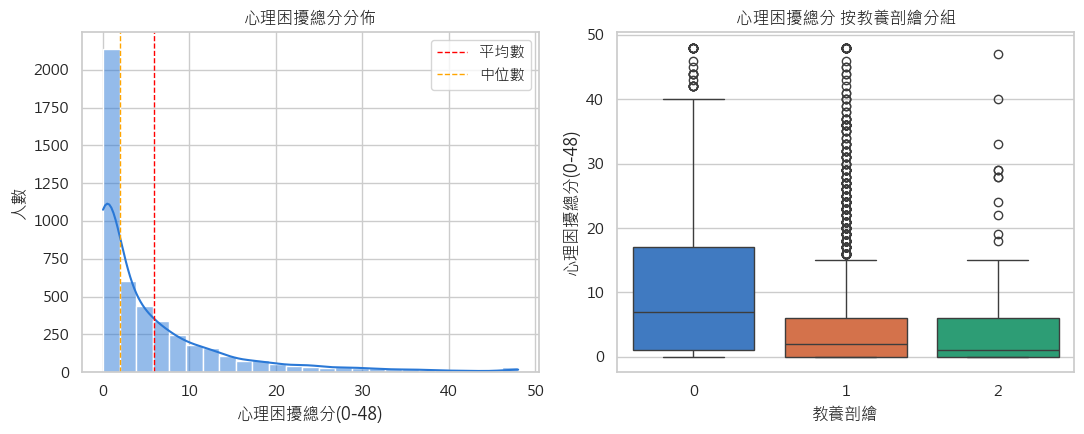

各剖繪心理困擾總分的描述統計：
                    count   mean    std  min  25%  50%   75%   max
parenting_profile                                                 
0                   817.0  10.71  11.64  0.0  1.0  7.0  17.0  48.0
1                  3734.0   4.79   7.71  0.0  0.0  2.0   6.0  48.0
2                   121.0   5.17   8.83  0.0  0.0  1.0   6.0  47.0


In [ ]:
plot_df = df.dropna(subset=['parenting_profile', 'distress_total']).copy()
plot_df['parenting_profile'] = plot_df['parenting_profile'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.histplot(df['distress_total'].dropna(), bins=25, kde=True, color=SEQ_BLUE, ax=axes[0])
axes[0].set_title('心理困擾總分分佈')
axes[0].set_xlabel('心理困擾總分(0-48)')
axes[0].set_ylabel('人數')
axes[0].axvline(df['distress_total'].mean(), color='red', linestyle='--', linewidth=1, label='平均數')
axes[0].axvline(df['distress_total'].median(), color='orange', linestyle='--', linewidth=1, label='中位數')
axes[0].legend()

profile_order = sorted(plot_df['parenting_profile'].unique())
sns.boxplot(data=plot_df, x='parenting_profile', y='distress_total',
            order=profile_order, hue='parenting_profile', legend=False,
            palette=CAT_PALETTE[:len(profile_order)], ax=axes[1])
axes[1].set_title('心理困擾總分 按教養剖繪分組')
axes[1].set_xlabel('教養剖繪')
axes[1].set_ylabel('心理困擾總分(0-48)')

plt.tight_layout()
plt.show()

print(plot_df.groupby('parenting_profile')['distress_total'].describe().round(2))

## 7. 單因子ANOVA 與 ANCOVA：教養剖繪 → 心理困擾

**方法說明**：先用單因子ANOVA看教養剖繪跟心理困擾關聯，再用ANCOVA(共變數分析)
控制性別、家庭結構、照顧者教育、家庭經濟、學業表現、同儕支持、霸凌與網路霸凌受害後，檢驗教養
剖繪是否仍有獨立效果。

ANCOVA本身建立在幾個統計假設上，做正式分析前先檢查：

1. **迴歸斜率同質性(homogeneity of regression slopes)**：假設每個控制變項對心理困擾的效果，在不同教養剖繪之間是一樣的。檢驗方式：多配一個「剖繪×所有控制變項」交互作用項的模型，
跟沒有交互作用的主效果模型做聯合F檢定，若顯著代表違反這個假設。
2. **變異數同質性(homogeneity of variance)**：假設各剖繪組內的依變項變異數相近，用 Levene's test檢驗。
3. **殘差常態性(normality of residuals)**：用Jarque-Bera檢定(比Shapiro-Wilk更適合大樣本)搭配Q-Q圖檢查。
4. **線性關係與同變異(linearity & homoscedasticity)**：用殘差對預測值的散佈圖檢查，如果殘差呈現漏斗狀或明顯曲線，代表線性或同變異假設可能有問題。
5. **獨立性(independence)**：ANCOVA假設觀測值彼此獨立。

In [33]:
cca_df = df.dropna(subset=['parenting_profile', 'distress_total'] + ANCOVA_CONTROLS).copy()
cca_df['parenting_profile'] = cca_df['parenting_profile'].astype(int).astype('category')
print(f"可用樣本: {len(cca_df)}")

# 單因子ANOVA，只看教養剖繪本身跟心理困擾的原始關聯
formula_anova_simple = "distress_total ~ C(parenting_profile)"
anova_simple_model = smf.ols(formula_anova_simple, data=cca_df).fit()
print("\n單因子ANOVA：")
print(anova_simple_model.summary().tables[1])

aov_simple = sm.stats.anova_lm(anova_simple_model, typ=2)
print("\n教養剖繪主效果(Type II ANOVA)：")
print(aov_simple.loc['C(parenting_profile)'])

可用樣本: 3489

單因子ANOVA：
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    10.4701      0.350     29.936      0.000       9.784      11.156
C(parenting_profile)[T.1]    -5.7293      0.383    -14.947      0.000      -6.481      -4.978
C(parenting_profile)[T.2]    -5.0577      0.916     -5.523      0.000      -6.853      -3.262

教養剖繪主效果(Type II ANOVA)：
sum_sq    1.553014e+04
df        2.000000e+00
F         1.117598e+02
PR(>F)    9.035077e-48
Name: C(parenting_profile), dtype: float64


In [34]:
formula_ancova = "distress_total ~ C(parenting_profile) + " + " + ".join(ANCOVA_CONTROLS)
main_effects_model = smf.ols(formula_ancova, data=cca_df).fit()

# 1. 迴歸斜率同質性
slope_formula = "distress_total ~ C(parenting_profile) * (" + " + ".join(ANCOVA_CONTROLS) + ")"
slope_model = smf.ols(slope_formula, data=cca_df).fit()
f_stat, f_p, _ = slope_model.compare_f_test(main_effects_model)
print(f"[假設1] 迴歸斜率同質性(交互作用聯合F檢定): F={f_stat:.3f}, p={f_p:.4f}")
print("  p<.05代表至少一個控制變項對心理困擾的效果，在不同教養剖繪間顯著不同(違反共同斜率假設)")

# 2. 變異數同質性
groups = [cca_df.loc[cca_df['parenting_profile'] == k, 'distress_total'] for k in sorted(cca_df['parenting_profile'].unique())]
levene_stat, levene_p = levene(*groups)
print(f"\n[假設2] 變異數同質性(Levene's test): W={levene_stat:.3f}, p={levene_p:.4f}")
print("  p<.05代表各剖繪組內心理困擾的變異程度不同")

# 3. 殘差常態性
resid = main_effects_model.resid
jb_stat, jb_p, skew, kurt = jarque_bera(resid)
print(f"\n[假設3] 殘差常態性(Jarque-Bera檢定): JB={jb_stat:.3f}, p={jb_p:.4f}, skew={skew:.3f}, kurtosis={kurt:.3f}")
print("  大樣本下常態性檢定容易對微小偏離也顯著，建議搭配Q-Q圖與偏態/峰度數值一起判斷嚴重程度")

[假設1] 迴歸斜率同質性(交互作用聯合F檢定): F=2.460, p=0.0006
  p<.05代表至少一個控制變項對心理困擾的效果，在不同教養剖繪間顯著不同(違反共同斜率假設)

[假設2] 變異數同質性(Levene's test): W=76.287, p=0.0000
  p<.05代表各剖繪組內心理困擾的變異程度不同

[假設3] 殘差常態性(Jarque-Bera檢定): JB=8975.901, p=0.0000, skew=2.083, kurtosis=9.662
  大樣本下常態性檢定容易對微小偏離也顯著，建議搭配Q-Q圖與偏態/峰度數值一起判斷嚴重程度


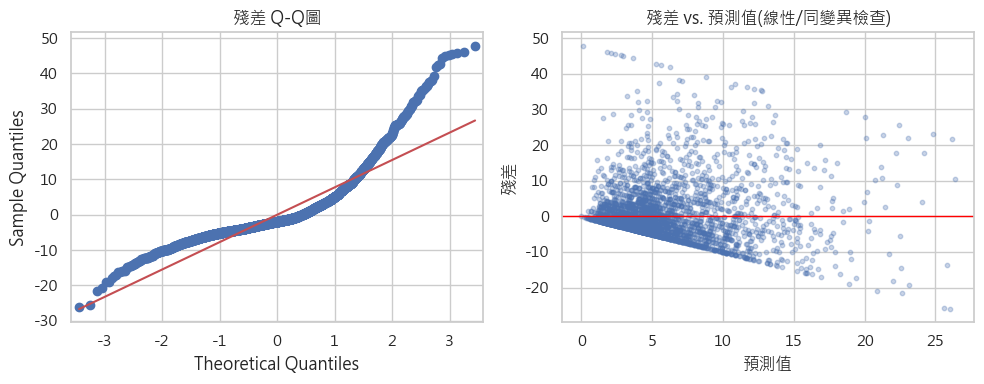

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sm.qqplot(resid, line='s', ax=axes[0])
axes[0].set_title('殘差 Q-Q圖')

axes[1].scatter(main_effects_model.fittedvalues, resid, alpha=0.3, s=10)
axes[1].axhline(0, color='red', linewidth=1)
axes[1].set_xlabel('預測值')
axes[1].set_ylabel('殘差')
axes[1].set_title('殘差 vs. 預測值(線性/同變異檢查)')
plt.tight_layout()
plt.show()

In [37]:
print(main_effects_model.summary().tables[1])

aov = sm.stats.anova_lm(main_effects_model, typ=2)
print("\n教養剖繪主效果 (Type II ANOVA，調整後)：")
print(aov.loc['C(parenting_profile)'])

                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     6.7220      1.225      5.489      0.000       4.321       9.123
C(parenting_profile)[T.1]    -3.8918      0.373    -10.433      0.000      -4.623      -3.160
C(parenting_profile)[T.2]    -3.1339      0.860     -3.643      0.000      -4.821      -1.447
male                         -2.3085      0.271     -8.527      0.000      -2.839      -1.778
family_intact                -0.5303      0.336     -1.579      0.114      -1.189       0.128
caregiver_edu                 0.1821      0.098      1.855      0.064      -0.010       0.375
family_ses                   -0.4397      0.254     -1.734      0.083      -0.937       0.057
academic_progress            -1.0737      0.157     -6.818      0.000      -1.383      -0.765
academic_rank                 0.2887      0.138      2.087  

**假設檢定結果與後續處理**：改用
異質變異穩健標準誤（HC3 heteroskedasticity-consistent standard errors）重新估計係數的標準誤與p值——對應變異數不同質的問題。

In [38]:
main_effects_model_robust = smf.ols(formula_ancova, data=cca_df).fit(cov_type='HC3')
print("ANCOVA（HC3穩健標準誤）：")
print(main_effects_model_robust.summary().tables[1])

print("\n一般OLS標準誤 vs. HC3穩健標準誤 對照(教養剖繪係數)：")
compare_robust = pd.DataFrame({
    '係數': main_effects_model.params, 'OLS_se': main_effects_model.bse, 'OLS_p': main_effects_model.pvalues,
    'HC3_se': main_effects_model_robust.bse, 'HC3_p': main_effects_model_robust.pvalues,
})
print(compare_robust[compare_robust.index.str.contains('parenting_profile')].round(4))
print("\n若HC3的p值判斷跟一般OLS一致，代表變異數不同質對這個結論的影響不大；若翻轉，應以HC3為準。")

ANCOVA（HC3穩健標準誤）：
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     6.7220      1.661      4.047      0.000       3.466       9.978
C(parenting_profile)[T.1]    -3.8918      0.477     -8.151      0.000      -4.828      -2.956
C(parenting_profile)[T.2]    -3.1339      1.012     -3.097      0.002      -5.117      -1.150
male                         -2.3085      0.274     -8.415      0.000      -2.846      -1.771
family_intact                -0.5303      0.366     -1.450      0.147      -1.247       0.186
caregiver_edu                 0.1821      0.112      1.624      0.104      -0.038       0.402
family_ses                   -0.4397      0.337     -1.303      0.193      -1.101       0.222
academic_progress            -1.0737      0.197     -5.452      0.000      -1.460      -0.688
academic_rank                 0.2887      

## 8. 機器學習：RandomForestRegressor / XGBRegressor

**超參數調整：Sobol序列搜尋**。用`scipy.stats.qmc.Sobol`在訓練集上生成低差異序列候選點，逐一
用5-fold交叉驗證(R²)評分後選最佳組合。Sobol序列是準隨機(quasi-random)序列，在同樣取樣預算下比單純隨機取樣對高維超參數空間的覆蓋更均勻。

In [21]:
ML_FEATURES = ['family_support', 'parent_warmth', 'parent_harsh', 'parent_monitor',
               'parent_involvement', 'parent_expect', 'academic_demand'] + ANCOVA_CONTROLS + ['net_addiction']

ml_df = df.dropna(subset=ML_FEATURES + ['distress_total']).copy()
print(f"機器學習可用樣本: N = {len(ml_df)}")

X = ml_df[ML_FEATURES]
y = ml_df['distress_total']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

機器學習可用樣本: N = 3246


In [22]:
RF_PARAM_SPECS = {
    'n_estimators': (100, 800, True), 'max_depth': (3, 15, True),
    'min_samples_leaf': (2, 30, True), 'max_features': (0.3, 1.0, False),
}
XGB_PARAM_SPECS = {
    'n_estimators': (100, 600, True), 'max_depth': (2, 8, True),
    'learning_rate': (0.01, 0.3, False), 'subsample': (0.5, 1.0, False),
    'colsample_bytree': (0.5, 1.0, False),
}
N_SOBOL_POW2 = 5  # 2**5 = 32 個候選超參數組合

rf_best_params, rf_search_results = sobol_hyperparam_search(
    RandomForestRegressor, RF_PARAM_SPECS, X_train, y_train, n_samples_pow2=N_SOBOL_POW2)
print(f"Random Forest：Sobol搜尋{len(rf_search_results)}組候選(5-fold CV R²)，最佳組合：{rf_best_params}")
print(f"最佳候選 CV R² = {rf_search_results.loc[0, 'cv_R2']:.4f}")

xgb_best_params, xgb_search_results = sobol_hyperparam_search(
    XGBRegressor, XGB_PARAM_SPECS, X_train, y_train, n_samples_pow2=N_SOBOL_POW2)
print(f"\nXGBoost：Sobol搜尋{len(xgb_search_results)}組候選(5-fold CV R²)，最佳組合：{xgb_best_params}")
print(f"最佳候選 CV R² = {xgb_search_results.loc[0, 'cv_R2']:.4f}")

Random Forest：Sobol搜尋32組候選(5-fold CV R²)，最佳組合：{'n_estimators': 786, 'max_depth': 13, 'min_samples_leaf': 5, 'max_features': np.float64(0.4444377457723021)}
最佳候選 CV R² = 0.2357

XGBoost：Sobol搜尋32組候選(5-fold CV R²)，最佳組合：{'n_estimators': 116, 'max_depth': 2, 'learning_rate': np.float64(0.054955551102757454), 'subsample': np.float64(0.708774859085679), 'colsample_bytree': np.float64(0.6266312375664711)}
最佳候選 CV R² = 0.2316


## 9. 逐步迴歸與LASSO選變數

除了RF/XGBoost，另外用兩種傳統迴歸方法當對照基準：逐步迴歸(BIC準則，分別只用主效果、以及開放
交互作用項讓模型自己選)，以及LASSO(交叉驗證選懲罰強度，候選集合同樣含主效果+兩兩交互作用)。

In [ ]:
rf = RandomForestRegressor(**rf_best_params, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

xgb = XGBRegressor(**xgb_best_params, random_state=RANDOM_STATE)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

# 逐步迴歸(stepwise, BIC準則)：「只允許主效果」跟「開放交互作用項讓模型自己選」
train_for_stepwise = X_train.copy()
train_for_stepwise['distress_total'] = y_train

sw_main_vars, sw_main_model = stepwise_select(train_for_stepwise, 'distress_total', ML_FEATURES,
                                               include_interactions=False)
sw_main_pred = sw_main_model.predict(X_test)
print(f"逐步迴歸(僅主效果)選入{len(sw_main_vars)}項: {sw_main_vars}")

sw_inter_vars, sw_inter_model = stepwise_select(train_for_stepwise, 'distress_total', ML_FEATURES,
                                                 include_interactions=True)
sw_inter_pred = sw_inter_model.predict(X_test)  
n_main = sum(1 for v in sw_inter_vars if ':' not in v)
n_inter = sum(1 for v in sw_inter_vars if ':' in v)
print(f"逐步迴歸(含交互作用候選)選入{len(sw_inter_vars)}項(主效果{n_main}+交互作用{n_inter}): {sw_inter_vars}")

逐步迴歸(僅主效果)選入7項: ['bully_victim', 'net_addiction', 'parent_harsh', 'male', 'family_support', 'cyberbully_victim', 'parent_involvement']
逐步迴歸(含交互作用候選)選入12項(主效果7+交互作用5): ['bully_victim', 'net_addiction', 'parent_harsh', 'male', 'bully_victim:male', 'net_addiction:parent_harsh', 'family_support', 'bully_victim:net_addiction', 'cyberbully_victim', 'bully_victim:cyberbully_victim', 'parent_involvement', 'cyberbully_victim:parent_involvement']


In [ ]:
# LASSO：主效果+兩兩交互作用的完整候選矩陣，標準化後用5-fold CV自動選懲罰強度alpha
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train[ML_FEATURES])
poly_names = poly.get_feature_names_out(ML_FEATURES)
X_train_poly_df = pd.DataFrame(X_train_poly, columns=poly_names, index=X_train.index)

scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly_df)
lasso_cv = LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=10000).fit(X_train_poly_scaled, y_train)
print(f"LassoCV選到的最佳alpha = {lasso_cv.alpha_:.4f}")

selected_terms = poly_names[lasso_cv.coef_ != 0]
n_main_sel = sum(1 for t in selected_terms if ' ' not in t)
n_inter_sel = sum(1 for t in selected_terms if ' ' in t)
print(f"LASSO選入{len(selected_terms)}項(主效果{n_main_sel}+交互作用{n_inter_sel}): {list(selected_terms)}")

# 用選出的變項，重新配適一般OLS
X_train_selected = build_design(X_train[ML_FEATURES], selected_terms)
X_test_selected = build_design(X_test[ML_FEATURES], selected_terms)

lasso_ols_model = sm.OLS(y_train, sm.add_constant(X_train_selected)).fit()
lasso_ols_pred = lasso_ols_model.predict(sm.add_constant(X_test_selected, has_constant='add'))

r2 = r2_score(y_test, lasso_ols_pred)
rmse = np.sqrt(mean_squared_error(y_test, lasso_ols_pred))
print(f"\nLASSO篩選+OLS重新配適: R²={r2:.4f}  RMSE={rmse:.3f}")

LassoCV選到的最佳alpha = 0.1568
LASSO選入21項(主效果4+交互作用17): ['family_support', 'parent_involvement', 'bully_victim', 'cyberbully_victim', 'family_support parent_expect', 'family_support family_ses', 'family_support peer_support', 'parent_warmth family_ses', 'parent_warmth academic_progress', 'parent_harsh parent_monitor', 'parent_harsh net_addiction', 'parent_monitor net_addiction', 'academic_demand academic_progress', 'academic_demand bully_victim', 'male bully_victim', 'male cyberbully_victim', 'male net_addiction', 'family_intact academic_progress', 'caregiver_edu bully_victim', 'caregiver_edu cyberbully_victim', 'academic_rank net_addiction']

LASSO篩選+OLS重新配適: R²=0.2048  RMSE=7.431


In [25]:
print("測試集表現：")
for name, pred in [('Random Forest', rf_pred), ('XGBoost', xgb_pred),
                    ('逐步迴歸-僅主效果', sw_main_pred),
                    ('逐步迴歸-含交互作用', sw_inter_pred),
                    ('LASSO+OLS重新配適', lasso_ols_pred)]:
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f"  {name:20s}: R²={r2:.4f}  RMSE={rmse:.3f}")

測試集表現：
  Random Forest       : R²=0.2293  RMSE=7.316
  XGBoost             : R²=0.2397  RMSE=7.267
  逐步迴歸-僅主效果           : R²=0.2065  RMSE=7.424
  逐步迴歸-含交互作用          : R²=0.1866  RMSE=7.516
  LASSO+OLS重新配適       : R²=0.2048  RMSE=7.431


In [39]:
print_model_table_and_equation(sw_main_model, label='逐步迴歸-僅主效果')
print_model_table_and_equation(sw_inter_model, label='逐步迴歸-含交互作用')
print_model_table_and_equation(lasso_ols_model, label='LASSO+OLS重新配適')

=== 逐步迴歸-僅主效果 ===
                        係數     標準誤      p值
Intercept          -4.3355  1.3652  0.0015
bully_victim        3.5768  0.3712  0.0000
net_addiction       0.2391  0.0246  0.0000
parent_harsh        0.4949  0.0537  0.0000
male               -2.6036  0.3013  0.0000
family_support     -0.8056  0.2481  0.0012
cyberbully_victim   2.5806  0.6150  0.0000
parent_involvement -0.8906  0.2818  0.0016

配適方程式：
distress_total = -4.336 + 3.577×bully_victim + 0.239×net_addiction + 0.495×parent_harsh - 2.604×male - 0.806×family_support + 2.581×cyberbully_victim - 0.891×parent_involvement

=== 逐步迴歸-含交互作用 ===
                                           係數     標準誤      p值
Intercept                            -15.0903  3.3746  0.0000
bully_victim                          10.8049  1.1749  0.0000
net_addiction                          0.0083  0.0820  0.9191
parent_harsh                          -0.3022  0.1437  0.0355
male                                   0.6419  0.8469  0.4486
bully_victim:male 

(                                       係數     標準誤      p值
 const                              0.9583  1.4374  0.5050
 family_support                    -0.4578  0.5360  0.3932
 parent_involvement                -0.7722  0.3004  0.0102
 bully_victim                       1.8256  1.6895  0.2800
 cyberbully_victim                  1.4891  1.8105  0.4109
 family_support:parent_expect      -0.0092  0.0223  0.6806
 family_support:family_ses          0.1573  0.1528  0.3035
 family_support:peer_support       -0.1227  0.0743  0.0987
 parent_warmth:family_ses          -0.0698  0.0338  0.0389
 parent_warmth:academic_progress    0.0157  0.0204  0.4415
 parent_harsh:parent_monitor        0.0285  0.0168  0.0895
 parent_harsh:net_addiction         0.0193  0.0026  0.0000
 parent_monitor:net_addiction       0.0070  0.0093  0.4502
 academic_demand:academic_progress -0.2027  0.0724  0.0052
 academic_demand:bully_victim       0.6575  0.2146  0.0022
 male:bully_victim                 -1.5493  0.7460  0.03

## 10. 特徵重要性

**特徵重要性排序**：
- **Random Forest**：**mean decrease in impurity（MDI，平均不純度下降量）**——每棵樹裡，這個特徵
  每次被用來切分節點時，帶來的MSE(不純度)下降量，依該節點涵蓋的樣本數加權平均到所有樹上，最後
正規化成全部特徵總和為1。
- **XGBoost**：sklearn包裝介面`feature_importances_`預設對應'gain'——該特徵在所有它被用來分裂的節點上，平均帶來多少訓練損失下降量，正規化成總和為1。

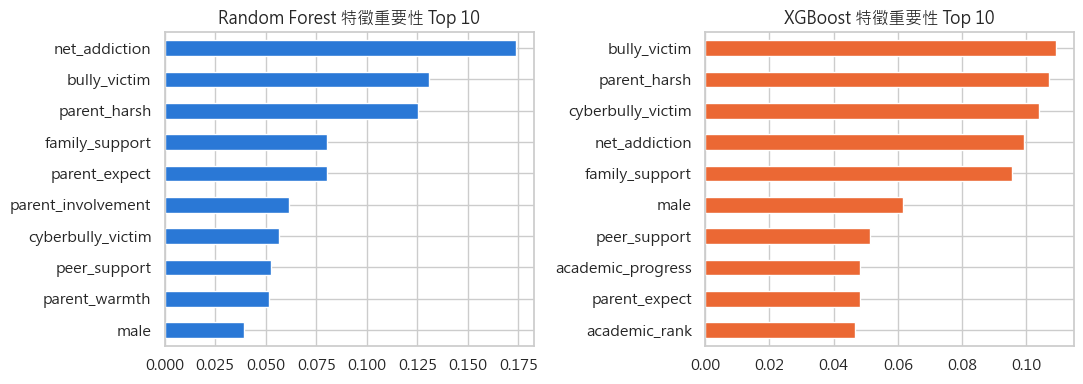

In [27]:
rf_importance = pd.Series(rf.feature_importances_, index=ML_FEATURES).sort_values(ascending=False)
xgb_importance = pd.Series(xgb.feature_importances_, index=ML_FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
rf_importance.head(10).sort_values().plot.barh(ax=axes[0], color=SEQ_BLUE)
axes[0].set_title('Random Forest 特徵重要性 Top 10')
xgb_importance.head(10).sort_values().plot.barh(ax=axes[1], color=CAT_PALETTE[1])
axes[1].set_title('XGBoost 特徵重要性 Top 10')
plt.tight_layout()
plt.show()

## 11. SHAP 特徵重要性

以XGBoost與Random Forest兩個模型各自計算SHAP值，逐樣本檢視每個特徵對心理困擾預測值的貢獻方向與大小（能同時看到重要性排序與影響方向）。

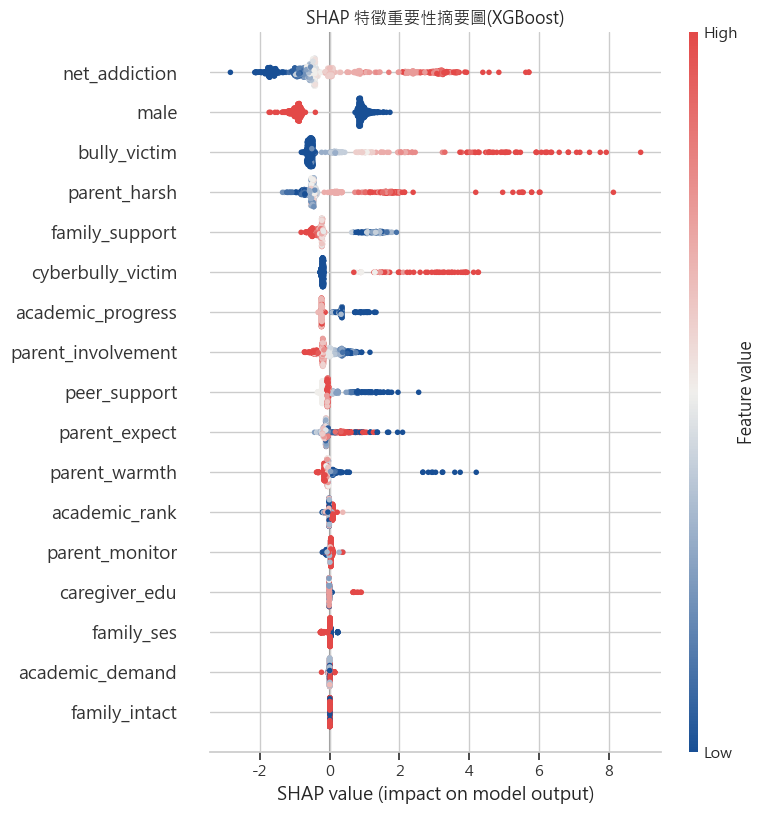

In [28]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, show=False, cmap=DIVERGING_CMAP)
plt.title('SHAP 特徵重要性摘要圖(XGBoost)')
plt.tight_layout()
plt.show()

**SHAP圖解讀**：每一列是一個特徵，由上到下依整體重要性(平均絕對SHAP值)排序；同一列上的每個
點是測試集裡的一筆學生資料。點的水平位置(x軸)代表SHAP值——這筆資料的這個特徵，把預測的心理
困擾分數往右推高多少(正值)或往左壓低多少(負值)，0代表這個特徵對這筆預測沒有額外貢獻(等於平均
基準線)。點的顏色代表這個特徵當下的原始數值高低(紅色高、藍色低)。

如果一個特徵「紅點集中在右邊、藍點集中在左邊」（例如`bully_victim`），代表
「這個特徵數值越高，越把心理困擾的預測值推高」，方向是正相關；反過來「紅點在左、藍點在右」則是
負相關(例如`peer_support`)。如果紅藍點混在一起沒有明顯的左右分化，代表這個特徵對預測的影響方向不穩定，可能有交互作用或非線性效果，不是簡單的線性關係。跟OLS係數的差別在於：OLS係數是
「平均而言、控制其他變項後」的單一效果數字，SHAP圖是「每一筆資料各自的貢獻」，能看出效果在不同
人身上是否一致。

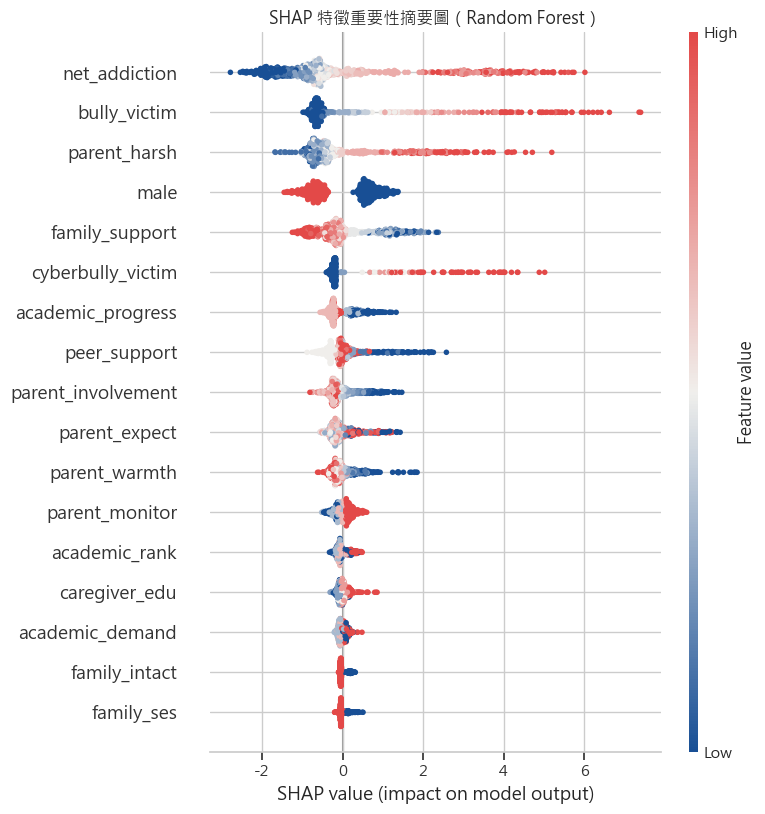

In [29]:
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values_rf, X_test, show=False, cmap=DIVERGING_CMAP)
plt.title('SHAP 特徵重要性摘要圖（Random Forest）')
plt.tight_layout()
plt.show()